# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
sentiment = pd.read_csv("fear_greed_index.csv")

# Inspect Data

In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
sentiment.shape

(2644, 4)

# Convert Date Column

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [ ]:
sentiment.dtypes

,0
timestamp,int64
value,int64
classification,object
date,datetime64[ns]


# Check Missing Values

In [ ]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


# Sentiment Distribution

In [ ]:
sentiment['classification'].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


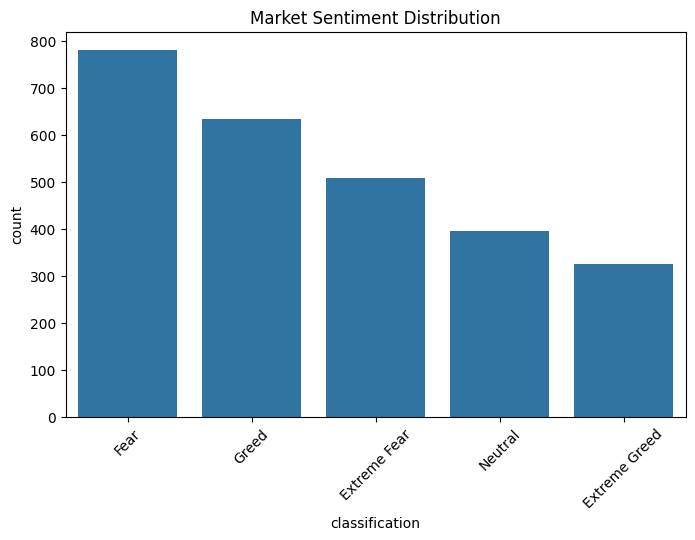

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=sentiment,
    x='classification',
    order=sentiment['classification'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Market Sentiment Distribution")
plt.show()

# Fear & Greed Percentage

In [ ]:
sentiment['classification'].value_counts(normalize=True)*100

,proportion
classification,
Fear,29.538578
Greed,23.940998
Extreme Fear,19.213313
Neutral,14.977307
Extreme Greed,12.329803


# Create Numerical Sentiment Score

In [ ]:
mapping = {
    'Extreme Fear':0,
    'Fear':1,
    'Neutral':2,
    'Greed':3,
    'Extreme Greed':4
}

sentiment['sentiment_score'] = sentiment[
    'classification'
].map(mapping)

In [ ]:
sentiment.head()

,timestamp,value,classification,date,sentiment_score
0,1517463000,30,Fear,2018-02-01,1
1,1517549400,15,Extreme Fear,2018-02-02,0
2,1517635800,40,Fear,2018-02-03,1
3,1517722200,24,Extreme Fear,2018-02-04,0
4,1517808600,11,Extreme Fear,2018-02-05,0


# Average Fear & Greed Index by Sentiment

In [ ]:
sentiment.groupby(
    'classification'
)['value'].mean()

,value
classification,
Extreme Fear,18.273622
Extreme Greed,82.116564
Fear,34.184379
Greed,65.846761
Neutral,49.964646


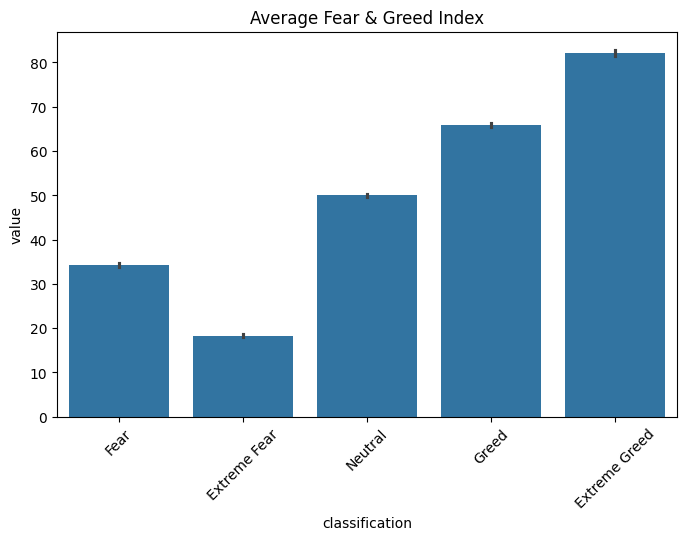

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment,
    x='classification',
    y='value'
)

plt.xticks(rotation=45)
plt.title("Average Fear & Greed Index")
plt.show()

# Year-wise Sentiment Analysis

In [ ]:
sentiment['year'] = sentiment['date'].dt.year

In [ ]:
yearly = pd.crosstab(
    sentiment['year'],
    sentiment['classification']
)

yearly

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
year,,,,,
2018,130,0,154,23,24
2019,57,24,153,97,34
2020,49,93,111,50,63
2021,64,93,72,106,30
2022,193,0,145,3,24
2023,0,1,48,164,152
2024,4,102,55,161,43
2025,11,13,43,29,26


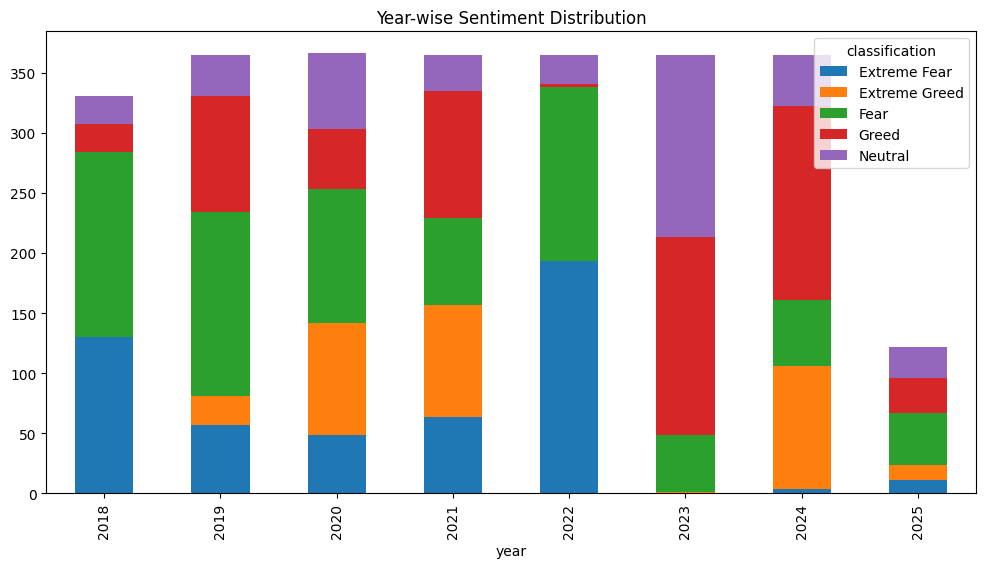

In [ ]:
yearly.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Year-wise Sentiment Distribution")
plt.show()

# Monthly Sentiment Trend

In [ ]:
monthly = sentiment.groupby(
    pd.Grouper(
        key='date',
        freq='M'
    )
)['value'].mean()

/tmp/ipykernel_5347/3295501578.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


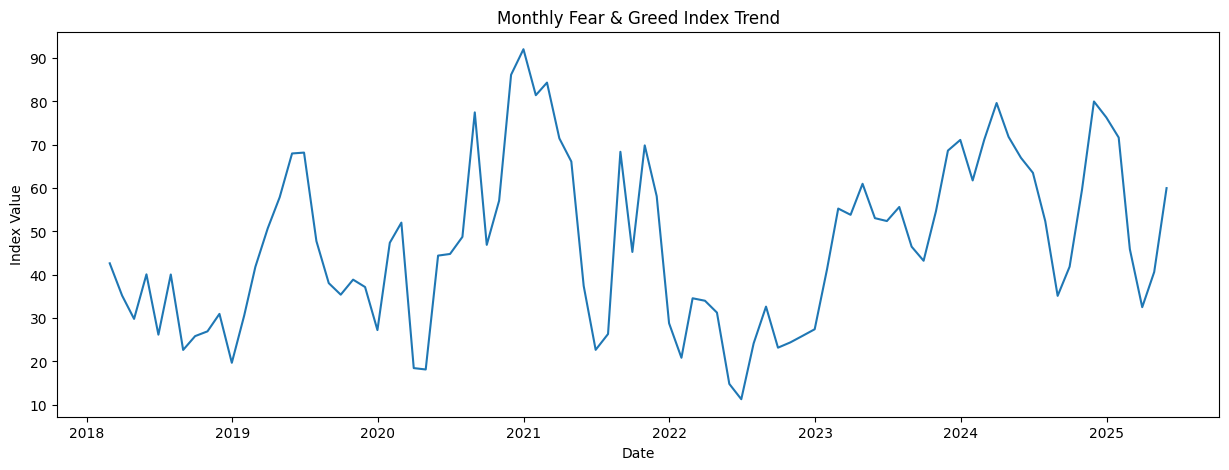

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly.index,
    monthly.values
)

plt.title("Monthly Fear & Greed Index Trend")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

# Fear vs Greed Comparison

In [ ]:
sentiment['market_state'] = sentiment[
    'classification'
].replace({
    'Extreme Fear':'Fear',
    'Fear':'Fear',
    'Extreme Greed':'Greed',
    'Greed':'Greed',
    'Neutral':'Neutral'
})

In [ ]:
sentiment['market_state'].value_counts()

,count
market_state,
Fear,1289
Greed,959
Neutral,396


# Save Clean Dataset

In [ ]:
sentiment.to_csv(
    "cleaned_sentiment.csv",
    index=False
)